# Parameters

In [5]:
from pathlib import Path
import sys

repo_root = Path.cwd().resolve()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from common.utils.parameters import (
    mcwf_dt_from_scales,
    omega_c,
    scaled_N_Gamma,
)
from common.utils.phases import default_three_phase_protocol
from parser.moments import MomentSeries

%reload_ext autoreload
%autoreload 2

output_dir = repo_root / "output"

### Parameters

In [6]:
# common fixed
Gamma = 1; num_snapshots=100
# param
dN = 0
Ni = [40,40]
omega_i = [0.7]
ntraj = 100
# Model and parameters
Omega_factor = 0.1
Omega0 = scaled_N_Gamma(Omega_factor, sum(Ni), Gamma)
delta_factor = 0.02
delta0 = scaled_N_Gamma(delta_factor, sum(Ni), Gamma)
dt = mcwf_dt_from_scales(Omega0, delta0, sum(Ni), Gamma)
# protocol phases
phases = default_three_phase_protocol(
    T1=10.0,
    T2=1000.0,
    T3=10.0,
    delta0=delta0,
    Omega0=Omega0,
)

total_time = float(sum(phase.duration for phase in phases))

Omega_c = omega_c(sum(Ni) // 2, Gamma)
print(f"Omega0 = {Omega0}")
print(f"Omega ratio = {Omega0 / Omega_c}")
print(f"delta0 = {delta0}")
print(f"dt = {dt}")

# dt = 1e-2

Omega0 = 8.0
Omega ratio = 0.4
delta0 = 1.6
dt = 0.00125


### Mean-field Equations

In [7]:
from solvers.mfe import compute_mfe_j_moments, solve_mfe
from parser.mfe import MFESolverParameters

# moment initialization
mfe_moments = MomentSeries(
    num_snapshots=num_snapshots,
    total_time=total_time,
    )

# Define method parameters and solve using mean-field equations
mfe_parameters = MFESolverParameters(
    Ni=tuple(Ni),
    omega_i=tuple(omega_i),
    Gamma=Gamma,
    phases=phases,
)
mfe_result = solve_mfe(
    mfe_parameters,
    t_eval=mfe_moments.t,
)

# compute moments
mfe_moments.J = compute_mfe_j_moments(mfe_result)

KeyboardInterrupt: 

### Monte-Carlo Wave Function

In [ ]:
from parser.mcwf import MCWFSolverParameters
from solvers.mcwf.ensamble_sim import run_trajectory_ensemble
from solvers.mcwf.j_moments import compute_mcwf_j_moments

# moment initialization
mcwf_moments = MomentSeries(
    num_snapshots=num_snapshots,
    total_time=total_time,
    )

# Define method parameters and simulate using Monte-Carlo wave function method
mcwf_parameters = MCWFSolverParameters(
    Ni=Ni,
    dN=dN,
    omega_i=omega_i,
    Gamma=Gamma,
    phases=phases,
    sector_distribution="binomial",
    dt=dt,
    shifted_jump_operator=True,
)
mcwf_ensemble = run_trajectory_ensemble(
    mcwf_parameters,
    t_eval=mcwf_moments.t,
    seed=1234,
    ntraj=ntraj,
    n_processes=-1,
    )

# compute moments
mcwf_moments.J = compute_mcwf_j_moments(
    mcwf_ensemble,
    n_processes=-1,
)

/Users/ashar/.pyenv/versions/cavity-OAT_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
simulate trajectories:  90%|█████████ | 90/100 [30:46<03:25, 20.51s/it]Process SpawnPoolWorker-6:
Process SpawnPoolWorker-8:
Process SpawnPoolWorker-10:
Process SpawnPoolWorker-2:
Process SpawnPoolWorker-5:
Process SpawnPoolWorker-7:
Process SpawnPoolWorker-4:
Process SpawnPoolWorker-1:
Process SpawnPoolWorker-3:

Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/Users/ashar/.pyenv/versions/3.12.3/lib/python3.

KeyboardInterrupt: 

### Qutip (mesolve & mcsolve)

### Plotting

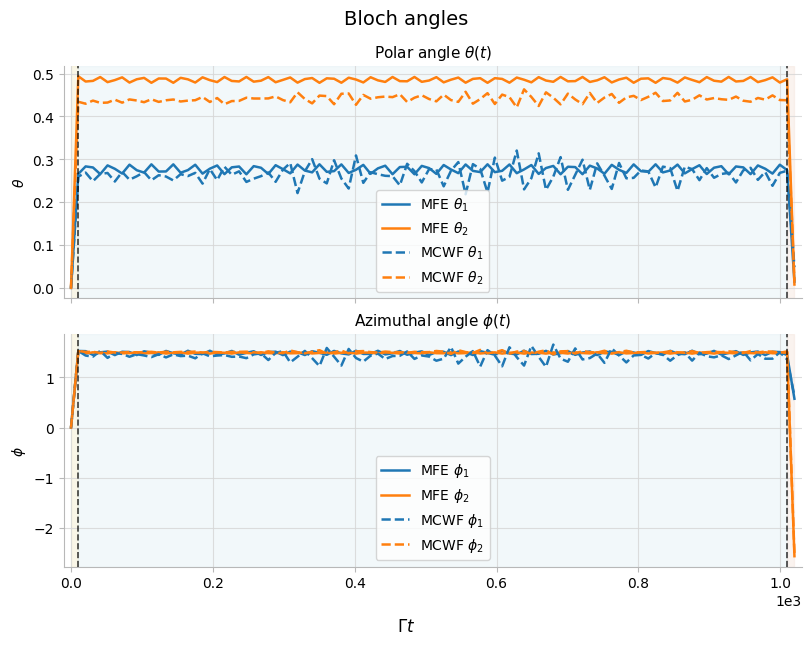

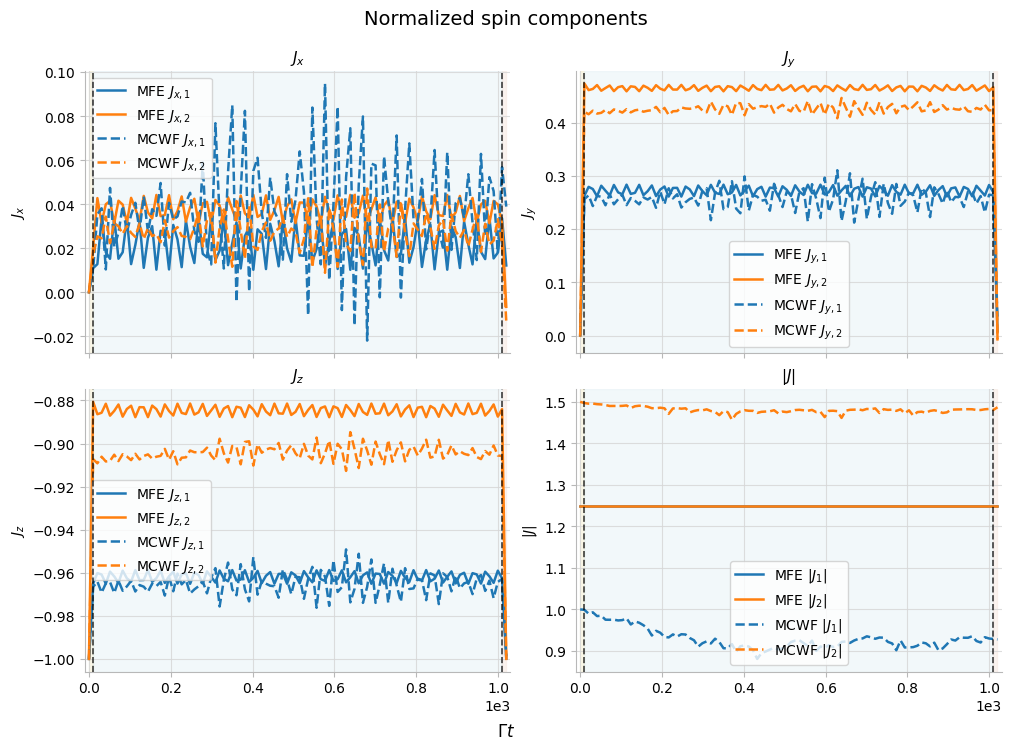

In [ ]:
from common.plotting import (
    plot_bloch_angles,
    plot_spin_components,
)


fig, axes = plot_bloch_angles(
    mfe_moments.J,
    phases=phases,
    label="MFE",
    colour_index=0,
    linestyle="-",
)
fig, axes = plot_bloch_angles(
    mcwf_moments.J,
    phases=phases,
    label="MCWF",
    colour_index=0,
    linestyle="--",
    axes=axes
)


normalized=True
fig, axes = plot_spin_components(
    mfe_moments.J,
    normalized=normalized,
    phases=phases,
    label="MFE",
    colour_index=0,
    linestyle="-",
)
fig, axes = plot_spin_components(
    mcwf_moments.J,
    normalized=normalized,
    phases=phases,
    label="MCWF",
    colour_index=0,
    linestyle="--",
    axes=axes,
)
